# Exploratory Data Analysis & Data Cleaning of Wisconsin Circuit Courts Dataset

**Source:** https://clezdata.github.io/wcld/  
**Reference:** Elliott Ash, Naman Goel, Nianyun Li, Claudia Marangon, & Peiyao Sun (ETH Zurich, University of Oxford)

**Coverage:** 1,476,967 cases filed 2000–2018 across Wisconsin counties in U.S.   
**Goal:** Predict recidivism (`recid_180d`) 

### Notebook Structure
1. Data Loading
2. Initial Data Overview
3. Missing Value Analysis
4. Target Variable Analysis (`recid_180d`)
5. Demographic Analysis
6. Offense & Charge Severity Analysis
7. Census Based Features
8. Prior Criminal History
9. Temporal Analysis
10. Data Cleaning & Cleaned Dataset
11. Feature Correlation & Summary

## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded.')

Libraries loaded.


In [2]:
DATA_PATH = 'C:\\Users\\miche\\Documents\\MSDS696_1\\wcld.csv'   

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Loaded {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded 1,476,967 rows × 54 columns


In [3]:
# Initial schema check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1476967 entries, 0 to 1476966
Data columns (total 54 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   county                      1476967 non-null  int64  
 1   new_id                      1476967 non-null  int64  
 2   sex                         1476967 non-null  object 
 3   race                        1476967 non-null  object 
 4   judge_id                    1476967 non-null  int64  
 5   case_type                   1476967 non-null  object 
 6   wcisclass                   1471484 non-null  object 
 7   age_offense                 1476967 non-null  int64  
 8   age_judge                   1476967 non-null  int64  
 9   prior_felony                1476967 non-null  int64  
 10  prior_misdemeanor           1476967 non-null  int64  
 11  prior_criminal_traffic      1476967 non-null  int64  
 12  highest_severity            1476967 non-null  float64
 1

## 2. Initial Data Overview

In [4]:
# Numeric summary
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
county,1476967.0,NaN,NaN,NaN,38.377929,19.820471,1.0,20.0,40.0,53.0,72.0
new_id,1476967.0,NaN,NaN,NaN,475880.874437,277182.053773,3.0,232946.0,474585.0,716877.0,958694.0
sex,1476967,2,M,1187413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,1476967,5,Caucasian,964922,NaN,NaN,NaN,NaN,NaN,NaN,NaN
judge_id,1476967.0,NaN,NaN,NaN,813.936822,462.670301,0.0,429.0,776.0,1185.0,1649.0
case_type,1476967,3,Misdemeanor,635668,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wcisclass,1471484,66,OAR/OAS,167104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_offense,1476967.0,NaN,NaN,NaN,30.920633,10.880847,14.0,22.0,28.0,38.0,150.0
age_judge,1476967.0,NaN,NaN,NaN,31.60455,10.922832,14.0,23.0,29.0,39.0,150.0
prior_felony,1476967.0,NaN,NaN,NaN,1.110371,1.809601,0.0,0.0,0.0,2.0,33.0


In [5]:
# Categorical column value counts
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}\n')
for col in cat_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False).to_string())
    print()

Categorical columns: ['sex', 'race', 'case_type', 'wcisclass', 'train_test_split_caselevel', 'train_test_split_deflevel', 'all_races']

--- sex ---
sex
M    1187413
F     289554

--- race ---
race
Caucasian                            964922
African American                     333036
Hispanic                             101607
American Indian or Alaskan Native     63862
Asian or Pacific Islander             13540

--- case_type ---
case_type
Misdemeanor         635668
Felony              475287
Criminal Traffic    366012

--- wcisclass ---
wcisclass
OAR/OAS                              167104
Operating While Intoxicated          166940
Drug Possession                      132357
Bail Jumping                         108458
Battery                              107245
Disorderly Conduct                   101315
Resisting Officer                     90077
Theft                                 69983
Criminal Damage                       37835
Retail Theft (Shoplifting)            36403
Burg

## 3. Missing Value Analysis

In [6]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct':   df.isnull().mean() * 100
}).sort_values('missing_pct', ascending=False)

missing_nonzero = missing[missing['missing_count'] > 0]
print(f'{len(missing_nonzero)} columns have missing values:\n')
display(missing_nonzero.round(2))

11 columns have missing values:



,missing_count,missing_pct
jail,836043,56.61
probation,444647,30.11
median_hist_jail,281590,19.07
avg_hist_jail,281590,19.07
min_hist_jail,281590,19.07
max_hist_jail,281590,19.07
recid_180d_violent,119212,8.07
recid_180d,119212,8.07
is_recid_new,69624,4.71
zip,40504,2.74


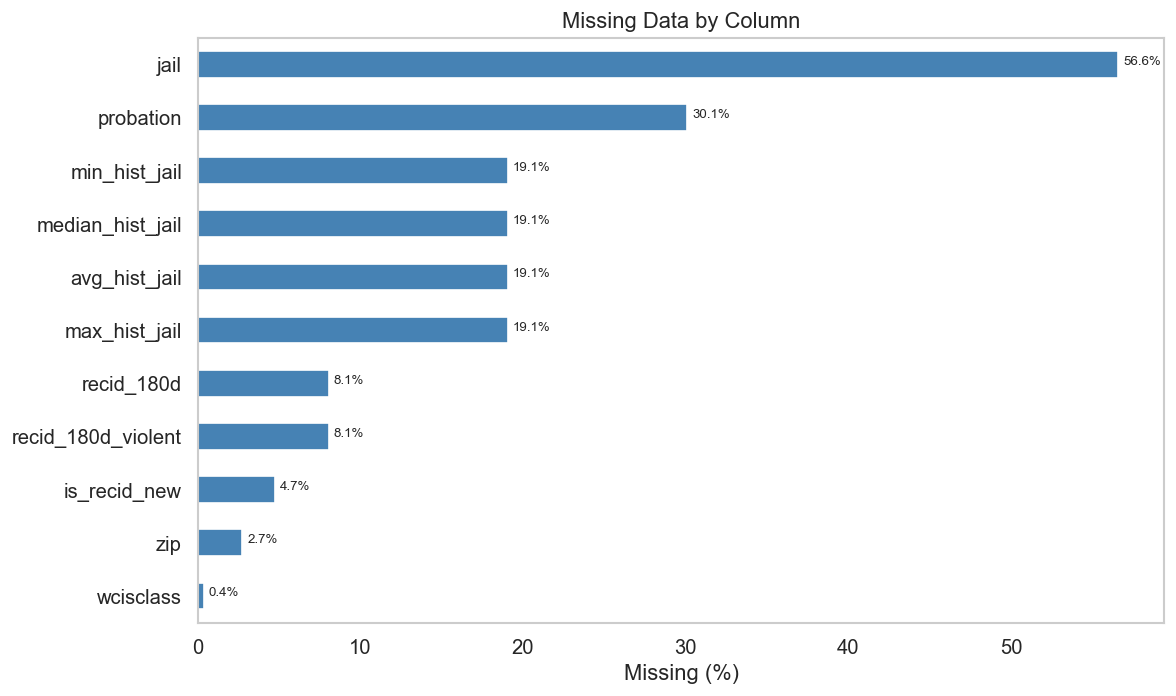

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
missing_nonzero['missing_pct'].sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)
ax.grid(False)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Column')
for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%", (p.get_width() + 0.3, p.get_y() + 0.25), fontsize=8)
plt.tight_layout()
plt.show()

# Notes on expected missingness from data source description
- Defendants with sentences >= 180 days cannot be observed for re-offense within follow-up window.
- `jail`: ~57% missing, only populated when jail sentence given.
- `probation`: ~30% missing, only when probation sentence given.
- `max_hist_jail`/`min_hist_jail`/`avg_hist_jail`/`median_hist_jail`: ~19% missing, no prior jail history.
- `wcisclass`: <1% missing, charge classification.
- `zip`: ~3% missing, address zip unavailable.

## 4. Target Variable Analysis

In [8]:
targets = ['recid_180d', 'recid_180d_violent', 'is_recid_new']

for t in targets:
    if t not in df.columns:
        continue
    vc = df[t].value_counts(dropna=False)
    total_obs = df[t].notna().sum()
    pos_rate = df[t].mean()
    print(f'\n{t}')
    print(f'  Observed (non-null): {total_obs:,}  ({total_obs/len(df)*100:.1f}% of dataset)')
    print(f'  Positive rate (recidivism): {pos_rate:.3f} ({pos_rate*100:.1f}%)')
    print(vc.to_string())


recid_180d
  Observed (non-null): 1,357,755  (91.9% of dataset)
  Positive rate (recidivism): 0.422 (42.2%)
recid_180d
0.0    784624
1.0    573131
NaN    119212

recid_180d_violent
  Observed (non-null): 1,357,755  (91.9% of dataset)
  Positive rate (recidivism): 0.088 (8.8%)
recid_180d_violent
0.0    1238869
NaN     119212
1.0     118886

is_recid_new
  Observed (non-null): 1,407,343  (95.3% of dataset)
  Positive rate (recidivism): 0.417 (41.7%)
is_recid_new
0.0    820739
1.0    586604
NaN     69624


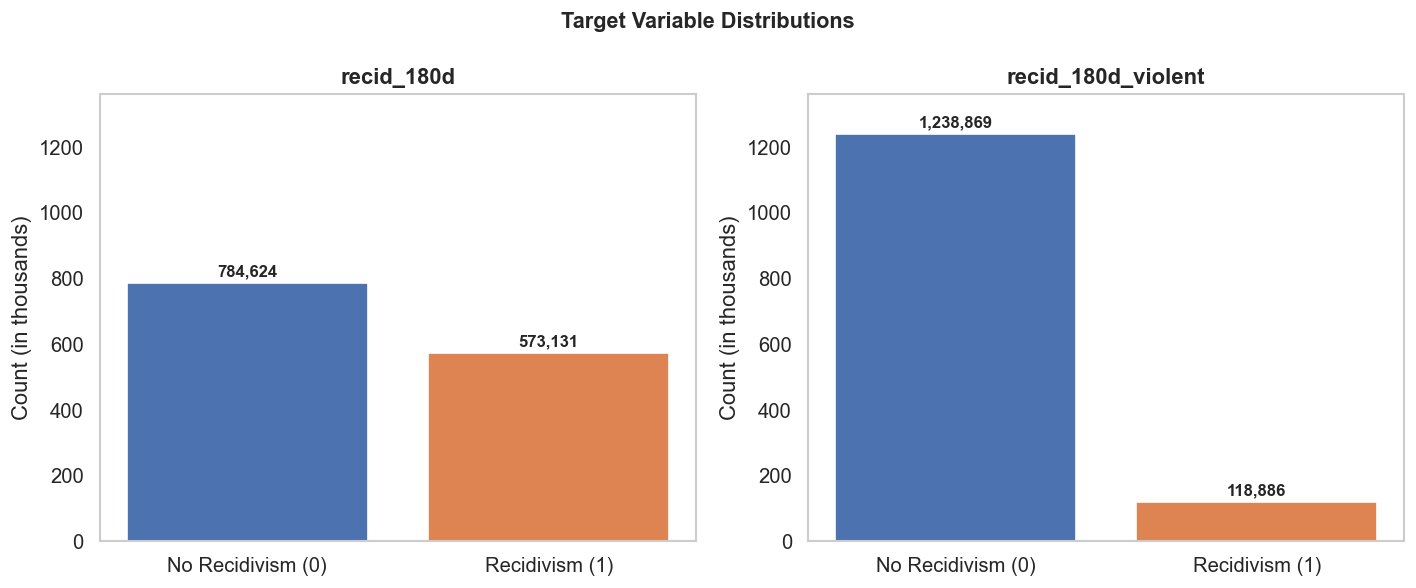

In [9]:
targets = ['recid_180d', 'recid_180d_violent']

max_count = max(
    df[t].value_counts(dropna=True).max()
    for t in targets
    if t in df.columns
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, t in zip(axes, targets):
    if t not in df.columns:
        continue

    counts = df[t].value_counts(dropna=True).sort_index()

    bars = ax.bar(
        ['No Recidivism (0)', 'Recidivism (1)'],
        counts.values / 1000,
        color=['#4C72B0', '#DD8452'],
        edgecolor='white'
    )

    ax.grid(False)
    ax.set_title(t, fontweight='bold')
    ax.set_ylabel('Count (in thousands)')

# Use the same y-axis maximum for both plots
    ax.set_ylim(0, max_count / 1000 * 1.10)

    for bar, count in zip(bars, counts.values):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + (max_count / 1000) * 0.01,
            f'{count:,}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

plt.suptitle(
    'Target Variable Distributions',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [10]:
summary_tables = []

for t in ['recid_180d', 'recid_180d_violent']:
    if t not in df.columns:
        continue

    counts = df[t].value_counts(dropna=True).sort_index()
    total = counts.sum()

    temp = pd.DataFrame({
        'Variable': t,
        'Value': counts.index,
        'Count': counts.values,
        'Percentage': (counts.values / total * 100).round(1)
    })

    summary_tables.append(temp)

target_summary = pd.concat(summary_tables, ignore_index=True)

target_summary['Value'] = target_summary['Value'].map({
    0: 'No Recidivism (0)',
    1: 'Recidivism (1)'
})

print(target_summary)

             Variable              Value    Count  Percentage
0          recid_180d  No Recidivism (0)   784624        57.8
1          recid_180d     Recidivism (1)   573131        42.2
2  recid_180d_violent  No Recidivism (0)  1238869        91.2
3  recid_180d_violent     Recidivism (1)   118886         8.8


,recid_rate,n_observed,n_recid,recid_rate_pct
race,,,,
American Indian or Alaskan Native,0.565,59480,33586.0,56.466
African American,0.464,290195,134745.0,46.433
Caucasian,0.403,900605,363262.0,40.335
Hispanic,0.388,94974,36813.0,38.761
Asian or Pacific Islander,0.378,12501,4725.0,37.797


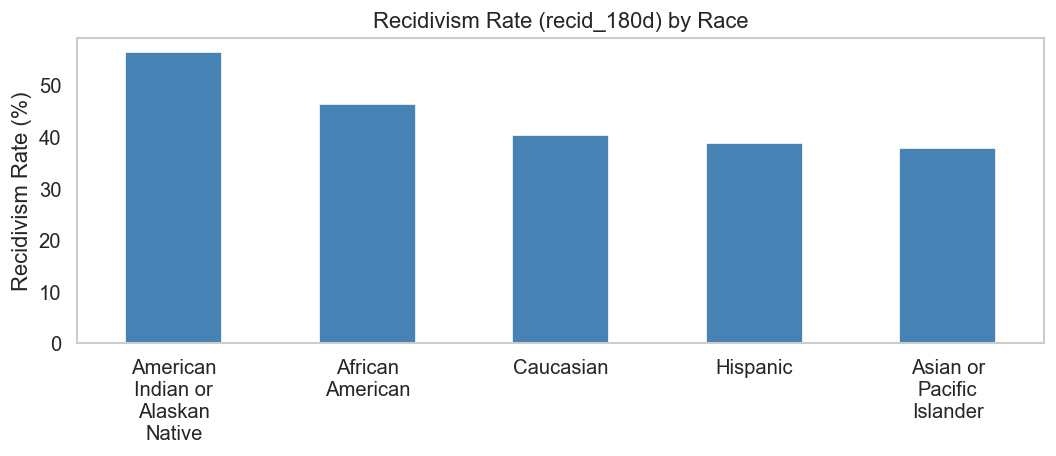

In [11]:
import textwrap

if 'race' in df.columns:
    recid_by_race = (df.groupby('race')['recid_180d']
                       .agg(['mean', 'count', 'sum'])
                       .rename(columns={'mean': 'recid_rate',
                                        'count': 'n_observed',
                                        'sum': 'n_recid'})
                       .sort_values('recid_rate', ascending=False))

    recid_by_race['recid_rate_pct'] = recid_by_race['recid_rate'] * 100
    display(recid_by_race.round(3))

    ax = recid_by_race['recid_rate_pct'].plot(
        kind='bar',
        color='steelblue',
        edgecolor='white',
        figsize=(9, 4)
    )

    ax.set_title('Recidivism Rate (recid_180d) by Race')
    ax.set_ylabel('Recidivism Rate (%)')
    ax.set_xlabel('')

    ax.grid(False)
    ax.xaxis.grid(False)
    ax.yaxis.grid(False)

    wrapped_labels = [
        textwrap.fill(str(label), width=12)
        for label in recid_by_race.index
    ]
    ax.set_xticklabels(wrapped_labels, rotation=0)

    plt.tight_layout()
    plt.show()

In [12]:
# Recidivism rate by sex
if 'sex' in df.columns:
    recid_by_sex = df.groupby('sex')['recid_180d'].agg(['mean', 'count']).rename(
        columns={'mean': 'recid_rate', 'count': 'n'})
    display(recid_by_sex.round(3))

,recid_rate,n
sex,,
F,0.350,278876
M,0.441,1078879


## 5. Demographic Analysis

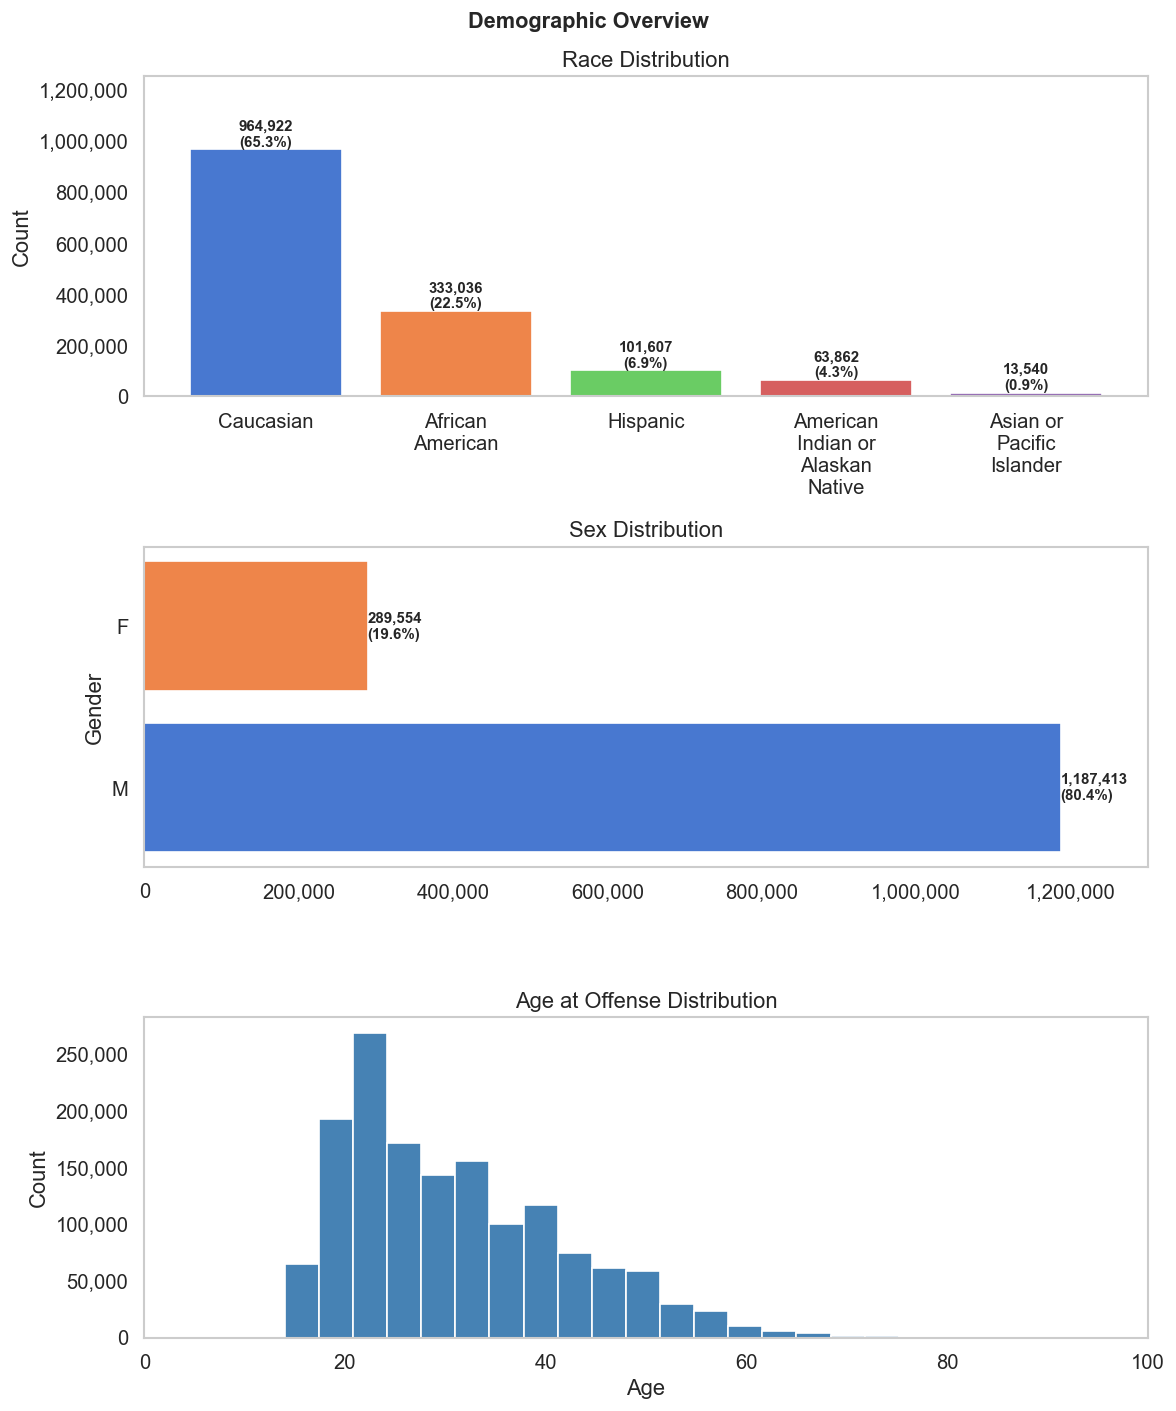

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Race distribution
race_col = 'race' if 'race' in df.columns else 'all_races'
rc = df[race_col].value_counts()
race_total = rc.sum()

race_labels = [textwrap.fill(str(label), width=12) for label in rc.index]

bars0 = axes[0].bar(
    race_labels,
    rc.values,
    color=sns.color_palette('muted', len(rc)),
    edgecolor='white'
)

axes[0].set_title('Race Distribution')
axes[0].set_ylabel('Count')

axes[0].set_ylim(0, 1_250_000)

axes[0].grid(False)
axes[0].xaxis.grid(False)
axes[0].yaxis.grid(False)

axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

for bar, count in zip(bars0, rc.values):
    pct = count / race_total * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count:,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Sex distribution 
if 'sex' in df.columns:
    sc = df['sex'].value_counts()
    
    order = [x for x in ['M', 'F'] if x in sc.index]
    sc = sc.reindex(order)

    total = sc.sum()

    bars1 = axes[1].barh(
        sc.index,
        sc.values,
        color=sns.color_palette('muted', len(sc)),
        edgecolor='white'
    )

    axes[1].set_title('Sex Distribution')
    axes[1].set_ylabel('Gender')

    axes[1].set_xlim(0, 1_300_000)

    axes[1].grid(False)
    axes[1].xaxis.grid(False)
    axes[1].yaxis.grid(False)

    axes[1].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
    )

    for bar, count in zip(bars1, sc.values):
        pct = count / total * 100
        axes[1].text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f'{count:,}\n({pct:.1f}%)',
            ha='left',
            va='center',
            fontsize=9,
            fontweight='bold'
        )

# Age distribution
if 'age_offense' in df.columns:
    axes[2].hist(
        df['age_offense'].dropna(),
        bins=40,
        color='steelblue',
        edgecolor='white'
    )

    axes[2].set_title('Age at Offense Distribution')
    axes[2].set_xlabel('Age')
    axes[2].set_ylabel('Count')

    axes[2].set_xlim(0, 100)

    axes[2].grid(False)
    axes[2].xaxis.grid(False)
    axes[2].yaxis.grid(False)

    axes[2].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
    )

plt.suptitle('Demographic Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Offense & Charge Severity Analysis

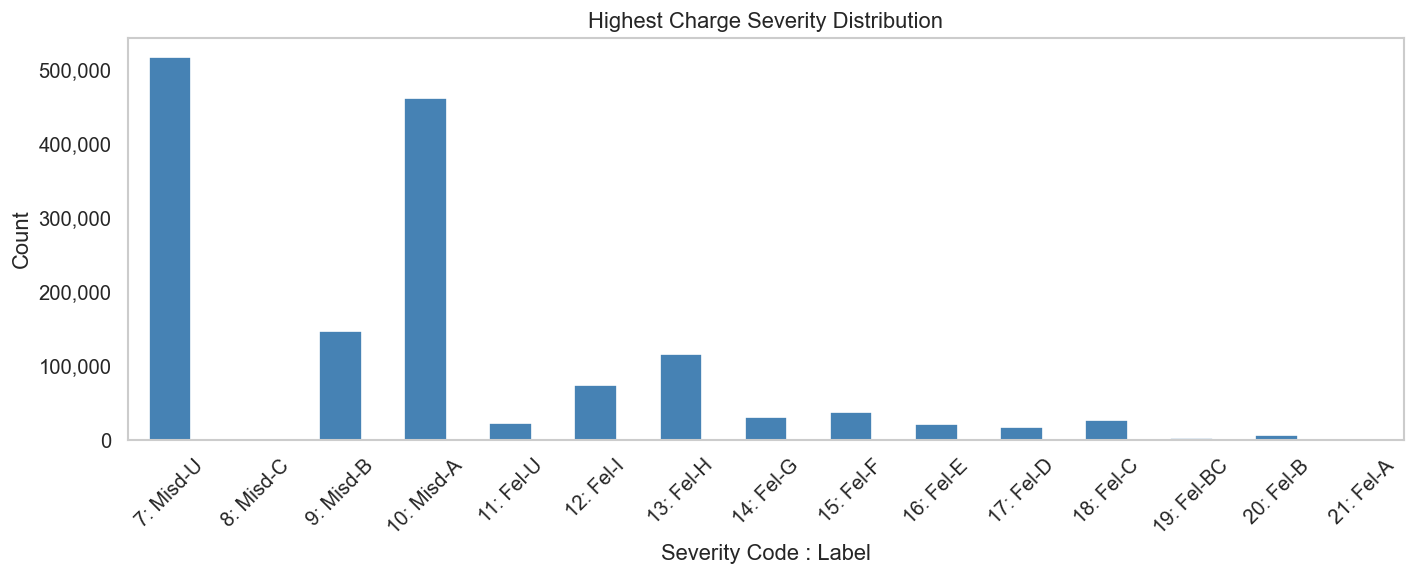

In [14]:
# Charge severity mapping from Wisconsin Circuit Court Access
severity_map = {
    7: 'Misd-U', 8: 'Misd-C', 9: 'Misd-B', 10: 'Misd-A',
    11: 'Fel-U',  12: 'Fel-I', 13: 'Fel-H', 14: 'Fel-G',
    15: 'Fel-F',  16: 'Fel-E', 17: 'Fel-D', 18: 'Fel-C',
    19: 'Fel-BC', 20: 'Fel-B', 21: 'Fel-A'
}

if 'highest_severity' in df.columns:
    sev_counts = df['highest_severity'].value_counts().sort_index()
    sev_counts.index = [f"{int(k)}: {severity_map.get(int(k), str(k))}" for k in sev_counts.index]

    fig, ax = plt.subplots(figsize=(12, 5))
    sev_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Highest Charge Severity Distribution')
    ax.set_xlabel('Severity Code : Label')
    ax.set_ylabel('Count')
    ax.grid(False)
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

In [15]:
if 'highest_severity' in df.columns:
    sev_counts = df['highest_severity'].value_counts().sort_index()

    total = sev_counts.sum()

    # Table format
    severity_table = pd.DataFrame({
        'Severity Code': sev_counts.index.astype(int),
        'Label': [severity_map.get(int(k), str(k)) for k in sev_counts.index],
        'Count': sev_counts.values,
        'Percentage': (sev_counts.values / total * 100).round(2)
    })

    severity_table['Severity'] = (
        severity_table['Severity Code'].astype(str) + ': ' + severity_table['Label']
    )

    severity_table = severity_table[
        ['Severity', 'Count', 'Percentage']
    ].sort_values('Count', ascending=False)

    display(severity_table)

,Severity,Count,Percentage
0,7: Misd-U,516004,34.94
3,10: Misd-A,460898,31.21
2,9: Misd-B,145750,9.87
6,13: Fel-H,116008,7.85
5,12: Fel-I,74062,5.01
8,15: Fel-F,37580,2.54
7,14: Fel-G,30561,2.07
11,18: Fel-C,26678,1.81
4,11: Fel-U,21893,1.48
9,16: Fel-E,21217,1.44


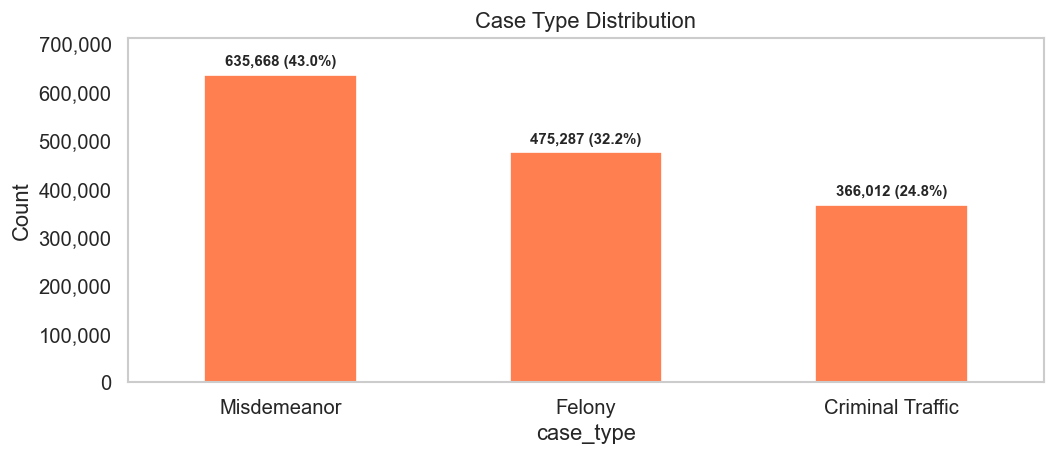

In [16]:
# Case Type distribution
if 'case_type' in df.columns:
    ct = df['case_type'].value_counts()
    total = ct.sum()

    fig, ax = plt.subplots(figsize=(9, 4))

    bars = ct.plot(
        kind='bar',
        ax=ax,
        color='coral',
        edgecolor='white'
    )

    ax.set_title('Case Type Distribution')
    ax.set_ylabel('Count')
    ax.grid(False)
    ax.tick_params(axis='x', rotation=0)

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
    )

    ymax = ct.max()
    ax.set_ylim(0, ymax * 1.12)

    for bar, count in zip(ax.patches, ct.values):
        pct = count / total * 100

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + ymax * 0.02,
            f'{count:,} ({pct:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

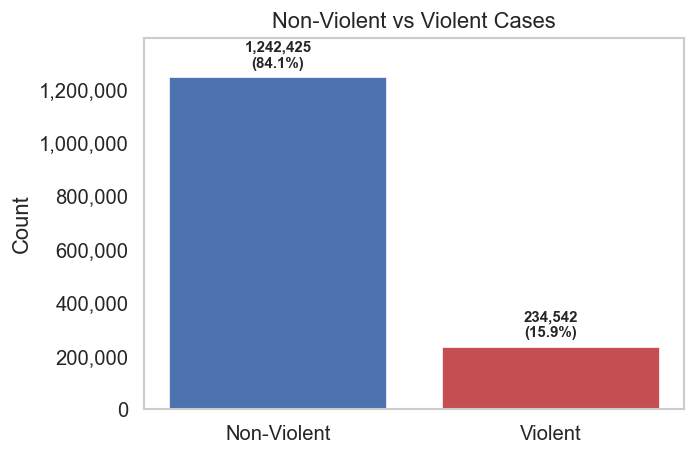

In [17]:
# Violent vs non-violent crime
if 'violent_crime' in df.columns:
    vc = df['violent_crime'].value_counts()
    total = vc.sum()

    labels = {0: 'Non-Violent', 1: 'Violent'}

    order = [0, 1]
    vc = vc.reindex(order)

    fig, ax = plt.subplots(figsize=(6, 4))

    bars = ax.bar(
        [labels.get(k, k) for k in vc.index],
        vc.values,
        color=['#4C72B0', '#C44E52'],
        edgecolor='white'
    )

    ax.set_title('Non-Violent vs Violent Cases')
    ax.set_ylabel('Count')

    ax.grid(False)
    ax.xaxis.grid(False)
    ax.yaxis.grid(False)

    ax.set_yticklabels([f'{int(tick):,}' for tick in ax.get_yticks()])

    ymax = vc.max()
    ax.set_ylim(0, ymax * 1.12)

    for bar, v in zip(bars, vc.values):
        pct = v / total * 100

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + ymax * 0.02,
            f'{v:,}\n({pct:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

## 7. Neighborhood & Census Features

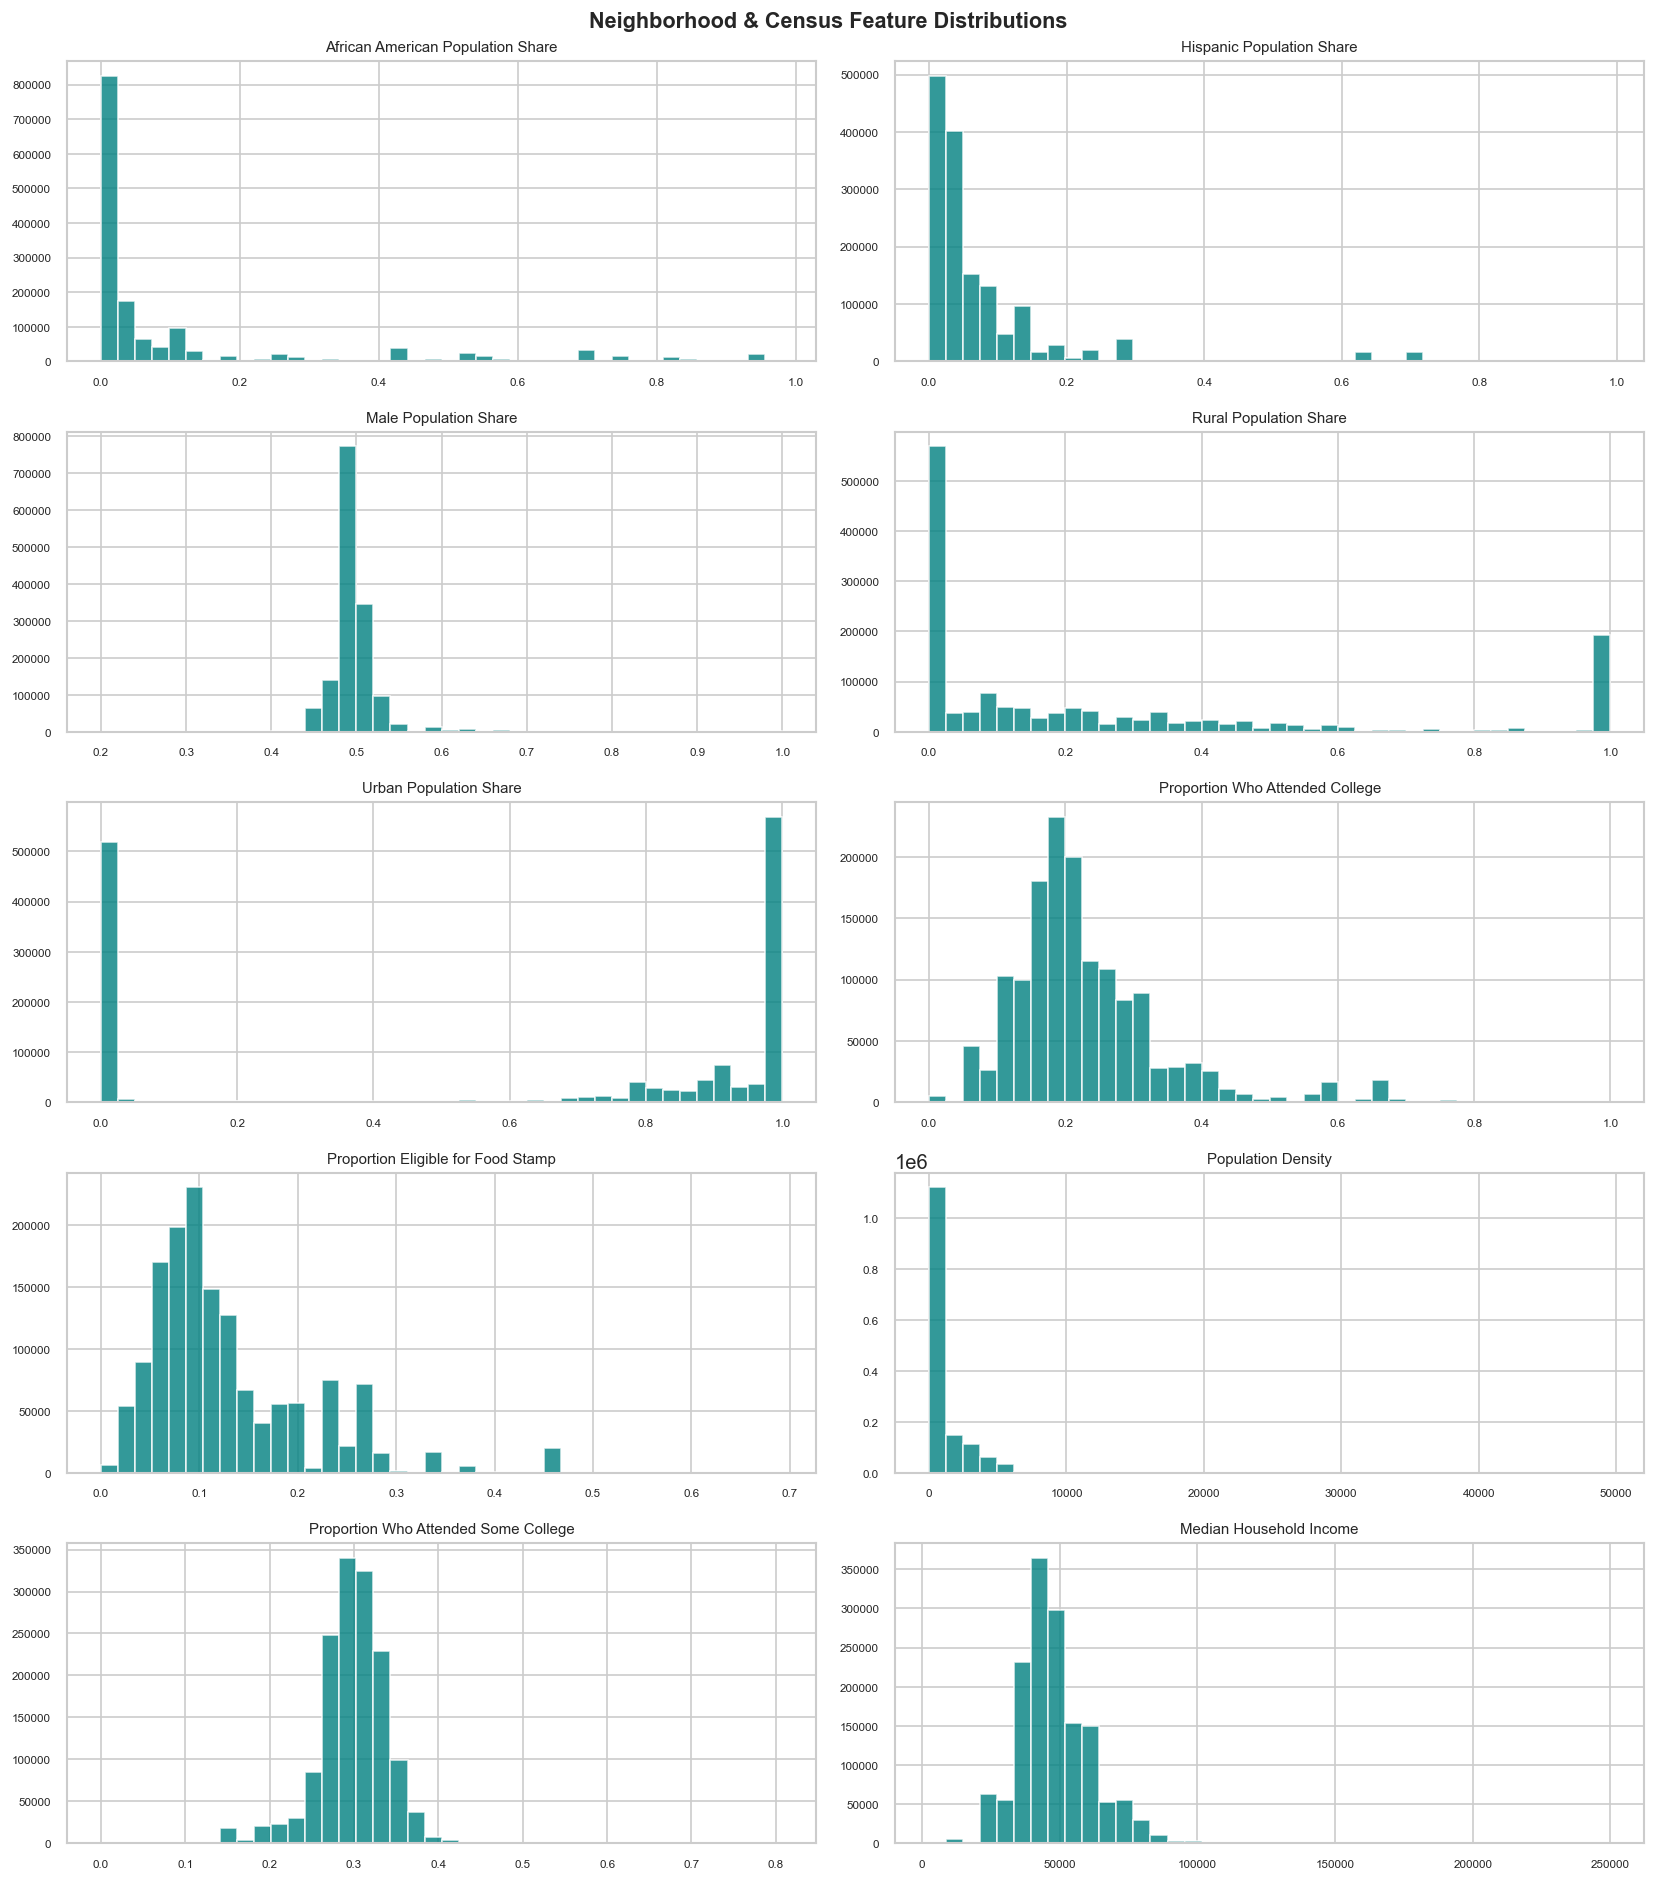

In [18]:
neighborhood_cols = [
    'pct_black', 'pct_hisp', 'pct_male', 'pct_rural', 'pct_urban',
    'pct_college', 'pct_food_stamps', 'pop_dens', 'pct_somecollege', 'med_hhinc'
]

existing_nc = [c for c in neighborhood_cols if c in df.columns]

# Custom titles mapped to columns
title_map = {
    'pop_dens': 'Population Density',
    'pct_college': 'Proportion Who Attended College',
    'pct_somecollege': 'Proportion Who Attended Some College',
    'pct_food_stamps': 'Proportion Eligible for Food Stamp',
    'pct_black': 'African American Population Share',
    'pct_hisp': 'Hispanic Population Share',
    'pct_male': 'Male Population Share',
    'pct_rural': 'Rural Population Share',
    'pct_urban': 'Urban Population Share',
    'med_hhinc': 'Median Household Income'
}

fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, col in zip(axes, existing_nc):
    ax.hist(
        df[col].dropna(),
        bins=40,
        color='teal',
        edgecolor='white',
        alpha=0.8
    )

    ax.set_title(title_map.get(col, col), fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes[len(existing_nc):]:
    ax.set_visible(False)

plt.suptitle(
    'Neighborhood & Census Feature Distributions',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [19]:
# Neighborhood & Census Feature Summary Table
summary_table = []

for col in existing_nc:
    summary_table.append({
        "Variable": title_map.get(col, col),
        "Count": df[col].count(),
        "Mean": df[col].mean(),
        "Std Dev": df[col].std(),
        "Min": df[col].min(),
        "25%": df[col].quantile(0.25),
        "Median": df[col].median(),
        "75%": df[col].quantile(0.75),
        "Max": df[col].max()
    })

summary_df = pd.DataFrame(summary_table)

summary_df = summary_df.round({
    "Mean": 3,
    "Std Dev": 3,
    "Min": 3,
    "25%": 3,
    "Median": 3,
    "75%": 3,
    "Max": 3
})

display(summary_df)

,Variable,Count,Mean,Std Dev,Min,25%,Median,75%,Max
0,African American Population Share,1476967,0.112,0.213,0.0,0.006,0.019,0.099,0.981
1,Hispanic Population Share,1476967,0.075,0.112,0.0,0.021,0.036,0.080,0.991
2,Male Population Share,1476967,0.498,0.034,0.2,0.486,0.495,0.504,1.000
3,Rural Population Share,1476967,0.261,0.339,0.0,0.000,0.102,0.378,1.000
4,Urban Population Share,1476967,0.594,0.457,0.0,0.000,0.892,1.000,1.000
5,Proportion Who Attended College,1476967,0.229,0.111,0.0,0.162,0.204,0.272,1.000
6,Proportion Eligible for Food Stamp,1476967,0.128,0.082,0.0,0.072,0.102,0.164,0.692
7,Population Density,1476967,886.986,1312.545,0.0,44.611,226.139,1237.443,49591.272
8,Proportion Who Attended Some College,1476967,0.299,0.042,0.0,0.280,0.302,0.324,0.808
9,Median Household Income,1476967,48250.279,13110.270,2499.0,40147.000,46321.000,55230.000,250001.000


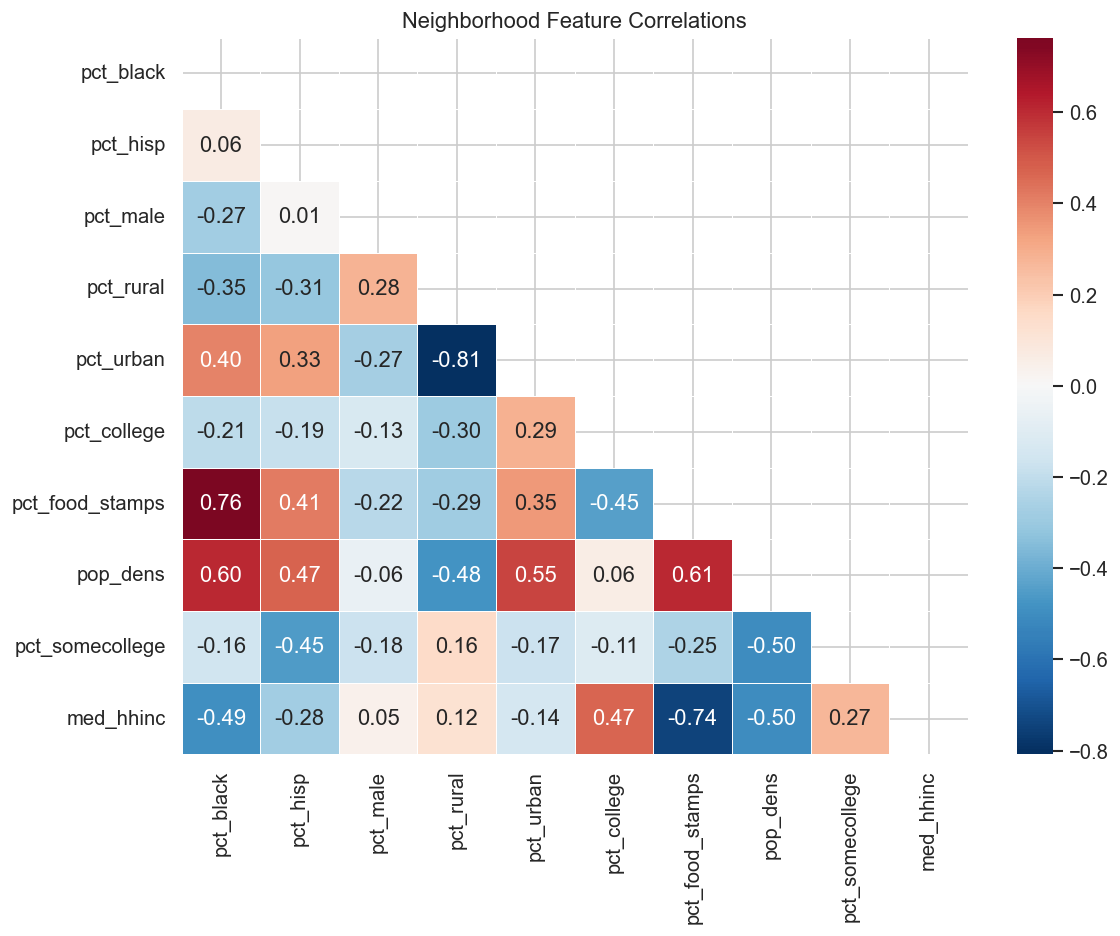

In [20]:
# Correlations among neighborhood features
corr = df[existing_nc].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Neighborhood Feature Correlations')
plt.tight_layout()
plt.show()

In [21]:
corr = df[existing_nc].corr()

corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack()
        .reset_index()
)

corr_pairs.columns = [
    'Variable 1',
    'Variable 2',
    'Correlation'
]

corr_pairs['Variable 1'] = corr_pairs['Variable 1'].map(title_map)
corr_pairs['Variable 2'] = corr_pairs['Variable 2'].map(title_map)

corr_pairs['Correlation'] = corr_pairs['Correlation'].round(2)

display(
    corr_pairs.sort_values(
        'Correlation',
        key=lambda x: x.abs(),
        ascending=False
    )
)

,Variable 1,Variable 2,Correlation
9,Urban Population Share,Rural Population Share,-0.81
15,Proportion Eligible for Food Stamp,African American Population Share,0.76
42,Median Household Income,Proportion Eligible for Food Stamp,-0.74
27,Population Density,Proportion Eligible for Food Stamp,0.61
21,Population Density,African American Population Share,0.60
25,Population Density,Urban Population Share,0.55
35,Proportion Who Attended Some College,Population Density,-0.50
43,Median Household Income,Population Density,-0.50
36,Median Household Income,African American Population Share,-0.49
24,Population Density,Rural Population Share,-0.48


## 8. Prior Criminal History

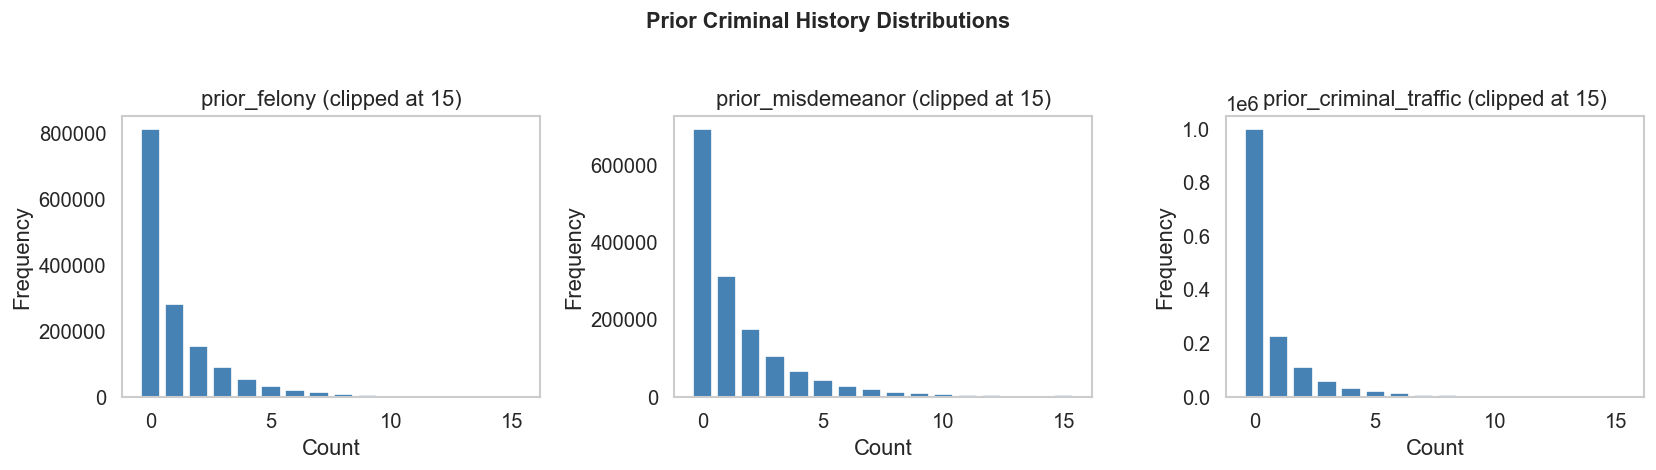

,prior_felony,prior_misdemeanor,prior_criminal_traffic
count,1476967.00,1476967.00,1476967.00
mean,1.11,1.47,0.74
std,1.81,2.29,1.51
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,0.00,1.00,0.00
75%,2.00,2.00,1.00
max,33.00,60.00,27.00


In [22]:
prior_cols = ['prior_felony', 'prior_misdemeanor', 'prior_criminal_traffic']
existing_pc = [c for c in prior_cols if c in df.columns]

fig, axes = plt.subplots(1, len(existing_pc), figsize=(14, 4))
for ax, col in zip(axes, existing_pc):
    data = df[col].clip(0, 15)  
    ax.hist(data, bins=range(0, 17), align='left', rwidth=0.8,
            color='steelblue', edgecolor='white')
    ax.set_title(f'{col} (clipped at 15)')
    ax.set_xlabel('Count')
    ax.set_ylabel('Frequency')
    ax.grid(False)
plt.suptitle('Prior Criminal History Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics
display(df[existing_pc].describe().round(2))

## 9. Temporal (Timeline) Analysis

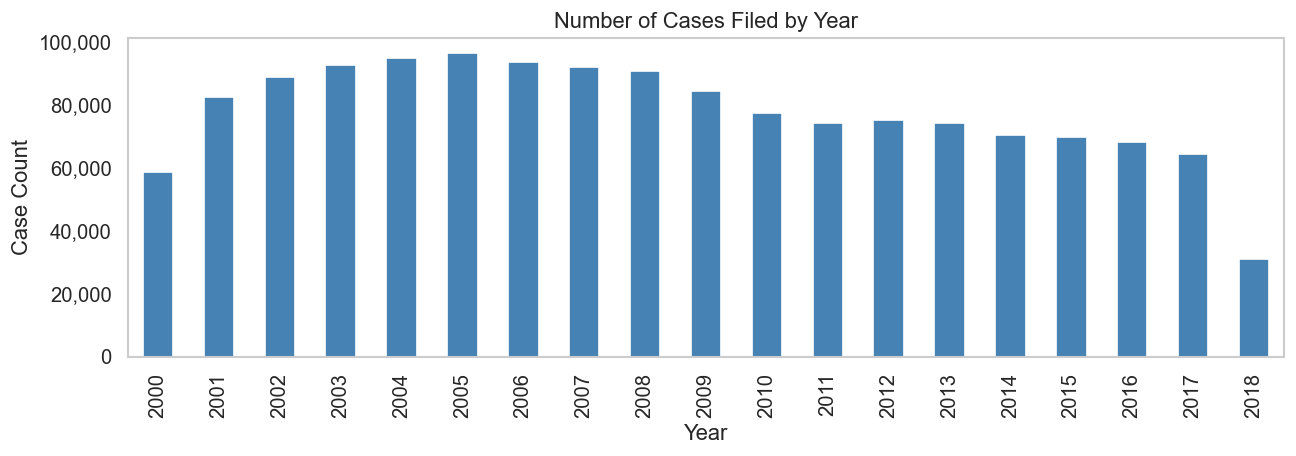

In [23]:
if 'year' in df.columns:
    yearly = df.groupby('year').size()
    fig, ax = plt.subplots(figsize=(11, 4))
    yearly.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Number of Cases Filed by Year')
    ax.set_xlabel('Year')
    ax.set_ylabel('Case Count')
    ax.grid(False)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

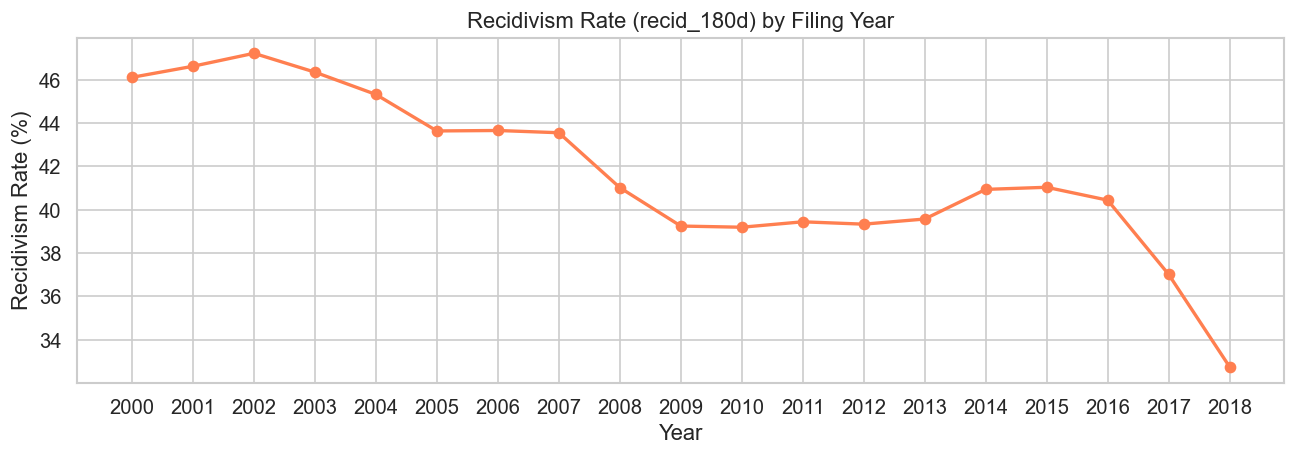

In [24]:
# Recidivism rate by year
if 'year' in df.columns and 'recid_180d' in df.columns:
    recid_yr = df.groupby('year')['recid_180d'].mean() * 100

    fig, ax = plt.subplots(figsize=(11, 4))

    recid_yr.plot(
        marker='o',
        ax=ax,
        color='coral',
        linewidth=2
    )

    ax.set_title('Recidivism Rate (recid_180d) by Filing Year')
    ax.set_ylabel('Recidivism Rate (%)')
    ax.set_xlabel('Year')

    ax.set_xticks(recid_yr.index.astype(int))
    ax.set_xticklabels(recid_yr.index.astype(int))

    plt.tight_layout()
    plt.show()

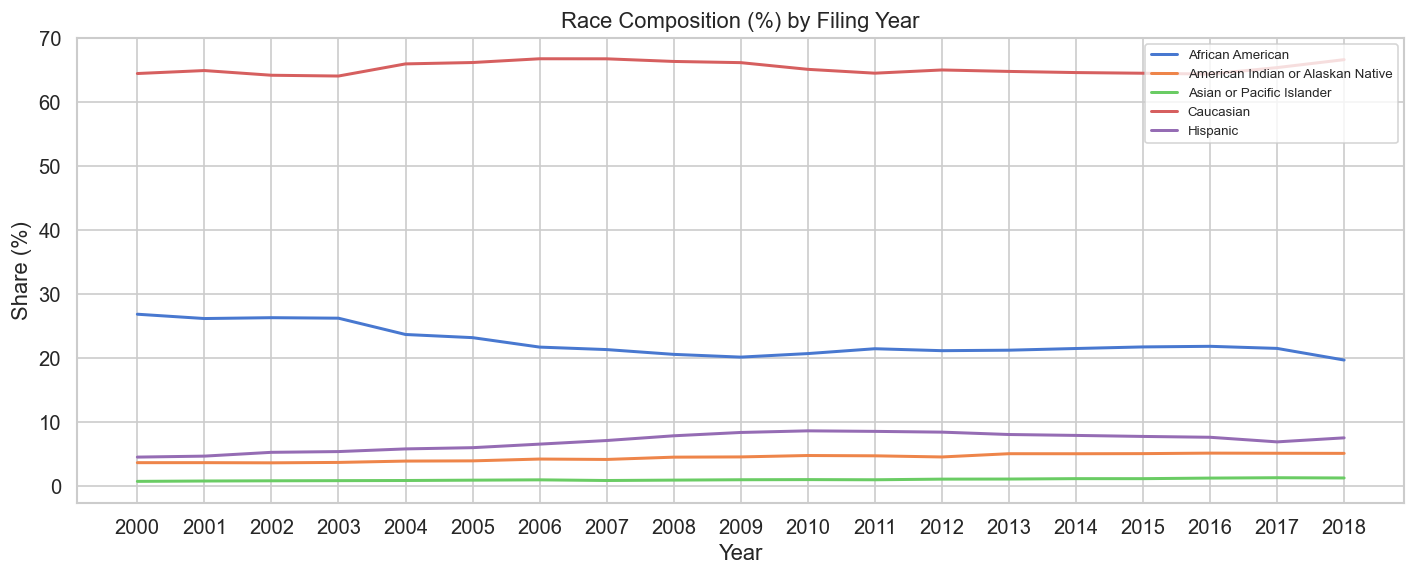

In [25]:
# Race composition over time
if 'year' in df.columns and race_col in df.columns:
    race_yr = df.groupby(['year', race_col]).size().unstack(fill_value=0)
    race_yr_pct = race_yr.div(race_yr.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(12, 5))

    race_yr_pct.plot(ax=ax, linewidth=1.8)

    ax.set_title('Race Composition (%) by Filing Year')
    ax.set_ylabel('Share (%)')
    ax.set_xlabel('Year')

    years = race_yr_pct.index.astype(int)
    ax.set_xticks(years)
    ax.set_xticklabels(years)

    ax.legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()

## 10. Data Cleaning & Final Dataset

In [26]:
df_clean = df.copy()
initial_rows = len(df_clean)
print(f'Starting rows: {initial_rows:,}')

Starting rows: 1,476,967


In [27]:
# Remove rows with impossible age values
if 'age_offense' in df_clean.columns:
    mask_bad_age = (df_clean['age_offense'] < 10) | (df_clean['age_offense'] > 100)
    n_bad = mask_bad_age.sum()
    df_clean = df_clean[~mask_bad_age]
    print(f'Removed {n_bad:,} rows with implausible age_offense (<10 or >100)')

print(f'Rows remaining: {len(df_clean):,}')

Removed 10 rows with implausible age_offense (<10 or >100)
Rows remaining: 1,476,957


In [28]:
# Fix negative time-to-judgment
if {'age_offense', 'age_judge'}.issubset(df_clean.columns):
    df_clean['time_to_judgment'] = df_clean['age_judge'] - df_clean['age_offense']
    neg_mask = df_clean['time_to_judgment'] < 0
    print(f'Flagging {neg_mask.sum():,} rows where age_judge < age_offense (data quality flag)')
    df_clean['flag_negative_time_to_judgment'] = neg_mask.astype(int)
    
print(f'Rows remaining: {len(df_clean):,}')

Flagging 36 rows where age_judge < age_offense (data quality flag)
Rows remaining: 1,476,957


In [29]:
# Impute jail history NaNs with 0 (no prior jail = 0 days)
jail_hist_cols = [c for c in ['max_hist_jail', 'min_hist_jail', 'avg_hist_jail', 'median_hist_jail']
                  if c in df_clean.columns]
for col in jail_hist_cols:
    n_null = df_clean[col].isna().sum()
    df_clean[col] = df_clean[col].fillna(0)
    print(f'  Filled {n_null:,} NaN → 0 in {col}')

print(f'Rows: {len(df_clean):,}')

  Filled 281,590 NaN → 0 in max_hist_jail
  Filled 281,590 NaN → 0 in min_hist_jail
  Filled 281,590 NaN → 0 in avg_hist_jail
  Filled 281,590 NaN → 0 in median_hist_jail
Rows: 1,476,957


In [30]:
# Create binary "has_prior_jail" indicator before imputation
df_clean['has_prior_jail'] = (df_clean['max_hist_jail'] > 0).astype(int)
print(f" 'has_prior_jail' created. {df_clean['has_prior_jail'].sum():,} defendants with prior jail.")

 'has_prior_jail' created. 296,231 defendants with prior jail.


In [31]:
# Encode categorical columns
cat_encode = {'sex': {'M': '1', 'F': '0'},}
for col, mapping in cat_encode.items():
    if col in df_clean.columns:
        df_clean[f'{col}_encoded'] = df_clean[col].map(mapping)
        print(f'  Encoded {col}: {mapping}')

# One-hot encode race
if race_col in df_clean.columns:
    race_dummies = pd.get_dummies(df_clean[race_col], prefix='race', drop_first=False, dtype=int)
    df_clean = pd.concat([df_clean, race_dummies], axis=1)
    print(f'  One-hot encoded {race_col}: {list(race_dummies.columns)}')

print(f'Columns: {df_clean.shape[1]}')

  Encoded sex: {'M': '1', 'F': '0'}
  One-hot encoded race: ['race_African American', 'race_American Indian or Alaskan Native', 'race_Asian or Pacific Islander', 'race_Caucasian', 'race_Hispanic']
Columns: 63


In [32]:
# Subset to rows with non-missing recid_180d for modeling
if 'recid_180d' in df_clean.columns:
    df_model = df_clean[df_clean['recid_180d'].notna()].copy()
    print(f'Model-ready subset (recid_180d observed): {len(df_model):,} rows')
    print(f'Dropped due to missing target: {len(df_clean) - len(df_model):,} rows')

Model-ready subset (recid_180d observed): 1,357,746 rows
Dropped due to missing target: 119,211 rows


In [33]:
# Cleaning summary
print('=' * 50)
print('DATA CLEANING SUMMARY')
print('=' * 50)
print(f'  Original rows:           {initial_rows:>10,}')
print(f'  Rows after cleaning:     {len(df_clean):>10,}')
if 'recid_180d' in df_clean.columns:
    print(f'  Model-ready subset:      {len(df_model):>10,}')
print(f'  Final columns:           {df_clean.shape[1]:>10}')
print()
remaining_na = df_model.isnull().sum() if 'df_model' in dir() else df_clean.isnull().sum()
leftover = remaining_na[remaining_na > 0]
if len(leftover) > 0:
    print('Remaining NaN columns in model dataset:')
    display(leftover.to_frame('null_count'))
else:
    print('No remaining NaN values in model dataset.')

DATA CLEANING SUMMARY
  Original rows:            1,476,967
  Rows after cleaning:      1,476,957
  Model-ready subset:       1,357,746
  Final columns:                   63

Remaining NaN columns in model dataset:


,null_count
wcisclass,5223
probation,442630
zip,35616
jail,828517


## 11. Feature Correlation & Summary

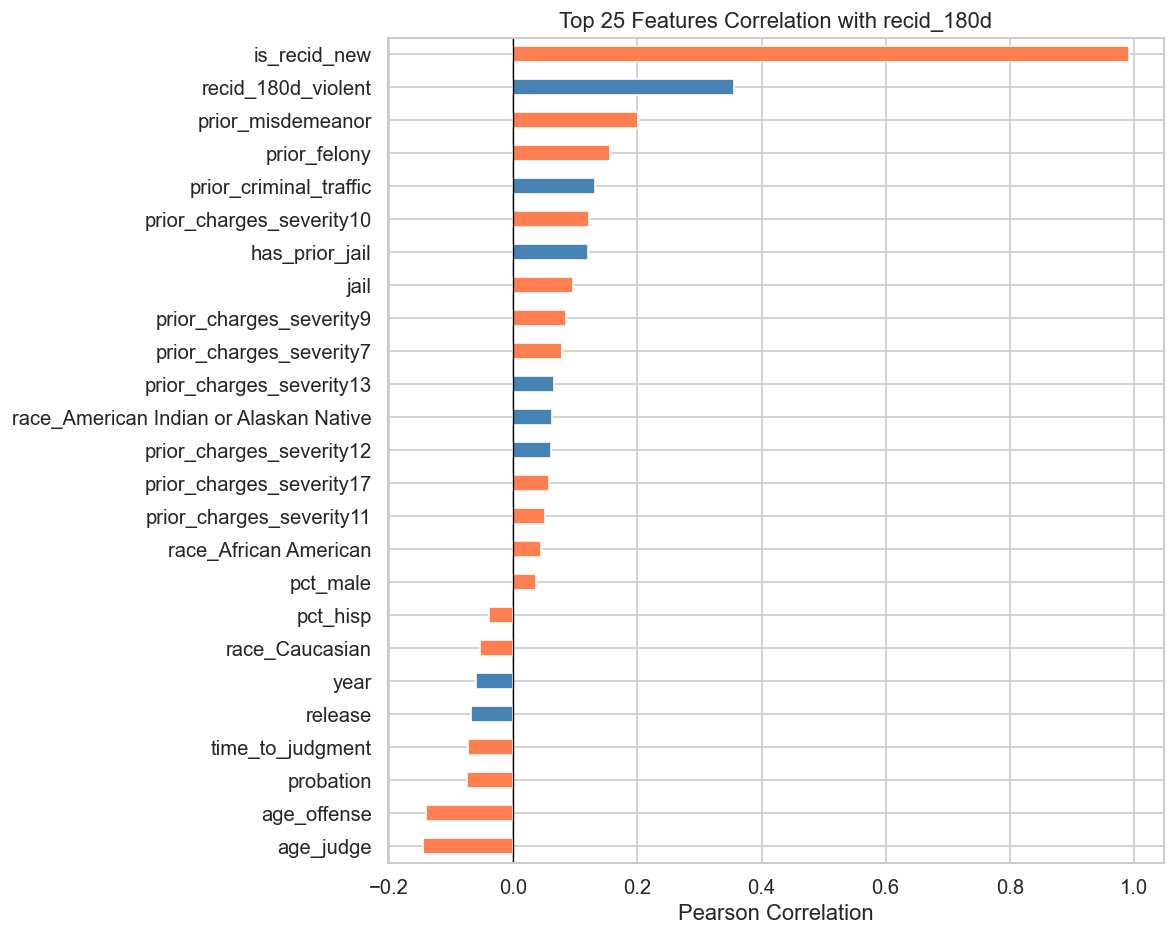

In [34]:
# Correlation of numeric features with recid_180d
if 'recid_180d' in df_model.columns:
    num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in ['recid_180d', 'new_id', 'judge_id']]

    corr_target = (df_model[num_cols + ['recid_180d']]
                   .corr()['recid_180d']
                   .drop('recid_180d')
                   .sort_values(key=abs, ascending=False)
                   .head(25))

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['coral' if v > 0 else 'steelblue' for v in corr_target.values]
    corr_target.sort_values().plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Top 25 Features Correlation with recid_180d')
    ax.set_xlabel('Pearson Correlation')
    plt.tight_layout()
    plt.show()

In [35]:
# Correlation table
if 'recid_180d' in df_model.columns:
    num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in ['recid_180d', 'new_id', 'judge_id']]

    corr_target = (
        df_model[num_cols + ['recid_180d']]
        .corr()['recid_180d']
        .drop('recid_180d')
        .sort_values(key=abs, ascending=False)
        .head(25)
    )

    corr_table = pd.DataFrame({
        'Feature': corr_target.index,
        'Correlation with recid_180d': corr_target.values,
        'Absolute Correlation': np.abs(corr_target.values)
    })

    corr_table['Correlation with recid_180d'] = (
        corr_table['Correlation with recid_180d'].round(3)
    )

    corr_table['Absolute Correlation'] = (
        corr_table['Absolute Correlation'].round(3)
    )

    display(corr_table)

,Feature,Correlation with recid_180d,Absolute Correlation
0,is_recid_new,0.992,0.992
1,recid_180d_violent,0.356,0.356
2,prior_misdemeanor,0.201,0.201
3,prior_felony,0.157,0.157
4,age_judge,-0.146,0.146
5,age_offense,-0.140,0.140
6,prior_criminal_traffic,0.132,0.132
7,prior_charges_severity10,0.122,0.122
8,has_prior_jail,0.121,0.121
9,jail,0.096,0.096


In [36]:
drop_cols = [
    'is_recid_new',
    'recid_180d_violent'
]

df_model = df_model.drop(
    columns=[col for col in drop_cols if col in df_model.columns]
)

In [37]:
# Save cleaned datasets
df_clean.to_csv('wcld_clean.csv', index=False)
if 'df_model' in dir():
    df_model.to_csv('wcld_model_ready.csv', index=False)

print('Saved:')
print('  wcld_clean.csv')
print('  wcld_model_ready.csv')

Saved:
  wcld_clean.csv
  wcld_model_ready.csv
